# NutriCoach — Deep Learning Capstone (single-notebook run)

Runs the **entire pipeline in one Colab runtime** so state persists throughout.
It drives the clean `src/nutricoach` modules (cloned from GitHub).

**Phase 1 (tabular):** calorie regression · Nutri-Score classification · Conditional VAE  
**Phase 2 (RAG):** knowledge corpus · domain-fine-tuned retriever · retrieval eval · RAG demo

> Set **Runtime → Change runtime type → GPU** before running.  
> Add a Colab Secret 🔑 `KAGGLE_API_TOKEN` (your Kaggle access token) for the dataset download.


## 🎯 Goal, motivation & research question

**Goal.** Build an end-to-end nutrition assistant that (a) analyses a food from its chemical composition and (b) answers natural-language nutrition questions — and make the two halves reinforce each other.

**Motivation.** Nutrition data is structured and abundant, which is perfect for classical ML *and* generative modelling; nutrition knowledge lives in text, which is perfect for RAG. Combining them into one product exercises most of the course (classic ML, VAE, Transformers, RAG).

**Research question (the experiment):** *Does adapting a general-purpose sentence encoder to the nutrition domain measurably improve retrieval quality — and can we do it without any manual labels?* This is the project's core, quantified with a baseline-vs-fine-tuned table.


## 🏗️ System architecture

Two phases. Phase-1 models are exposed as callable *tools* that the Phase-2 assistant invokes.

```
PHASE 1 (tabular)                         PHASE 2 (RAG)
Open Food Facts                           Wikipedia corpus (20 articles → 905 chunks)
   │ clean                                   │ chunk + embed
   ▼                                          ▼
 8 nutrients ──┬─► Regressor  → kcal        FAISS index
               ├─► Classifier → Nutri-Score    │ query
               └─► CVAE       → new profile     ▼
                                            Retriever (fine-tuned)  ── top-k ─►  LLM ─► answer + citations
                                                                                   ▲
        Phase-1 models are called as TOOLS ────────────────────────────────────────┘
```

**Deliverables:** GitHub repo, trained artifacts on the HF Hub, and a live Gradio chatbot on HF Spaces.


## 🧭 Methodology & design choices

- **Dataset — Open Food Facts (Kaggle subset).** Chosen because it is the only large open food dataset that ships the **Nutri-Score** grade, which we need for the classification and the conditional generation tasks.
- **Tabular models — Random Forest / XGBoost / MLP.** We compare a bagging tree, a boosting tree and a neural net to see which fits noisy tabular data best, rather than assuming one winner.
- **Generation — Conditional VAE (not a plain VAE).** Conditioning on the target grade lets us *control* what we generate ("make a grade-A profile"), which a plain VAE cannot.
- **Retriever base — `all-MiniLM-L6-v2`.** A small, general encoder: fast on free hardware and with enough headroom that domain fine-tuning produces a visible improvement.
- **Training signal — synthetic (question, passage) pairs.** An LLM writes questions for each chunk, so we fine-tune with **zero manual labels** (the GPL/InPars idea).
- **Fine-tuning loss — MultipleNegativesRankingLoss.** The standard, data-efficient recipe for sentence-transformer retrieval.
- **Generator — `Qwen2.5-1.5B-Instruct`.** Small enough to run on free compute, instruction-tuned for clean answers.


## 0 · Setup (clone repo, install, Kaggle auth)


In [3]:
import sys, os, subprocess
IN_COLAB = 'google.colab' in sys.modules
REPO_URL = 'https://github.com/shekeraoleksandr/AI-NutriCoach.git'

if IN_COLAB:
    repo = '/content/AI-NutriCoach'
    if not os.path.exists(repo):
        subprocess.run(['git', 'clone', REPO_URL, repo], check=True)
    os.chdir(repo)
    subprocess.run(['git', 'pull'], check=False)
    subprocess.run(['pip', 'install', '-q', '-r', 'requirements.txt'], check=True)
    subprocess.run(['pip', 'install', '-q', 'wikipedia'], check=True)
    try:
        from google.colab import userdata
        os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')
    except Exception as e:
        print('!! Add Colab Secret KAGGLE_API_TOKEN (or an access_token file). ', e)

sys.path.insert(0, 'src')
print('cwd:', os.getcwd(), '| Colab:', IN_COLAB)


cwd: /content/AI-NutriCoach | Colab: True


In [4]:
from nutricoach import (config as C, data, models_tabular as M, cvae,
                        ingest, retriever, pairs, rag, evaluate as E)
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, torch
print('modules loaded · GPU available:', torch.cuda.is_available())


modules loaded · GPU available: True


---
# Phase 1 — Tabular nutrition analysis


## 1.1 · Download & clean


In [5]:
csv_path = data.download_raw()          # Open Food Facts via kagglehub
df = data.load_clean(csv_path)
print('shape:', df.shape)
df.head()


100%|██████████| 66.2M/66.2M [00:03<00:00, 21.9MB/s]

Extracting files...


shape: (87164, 12)


,energy_kcal_100g,proteins_100g,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,salt_100g,sodium_100g,nutriscore_grade,product_name,generic_name
0,290.0,22.00,12.00,7.000,23.0,0.00,2.00,2.160,0.864,d,Salade Cesar,Laitue en salade
1,260.0,3.33,10.70,2.000,38.7,24.70,2.00,0.647,0.259,c,Chaussons tressés aux pommes,Pâtisserie
2,278.0,10.00,1.11,0.333,53.3,1.11,2.22,1.520,0.610,b,Pain Burger Artisan,Pain
3,561.0,8.20,53.20,9.600,11.7,0.50,1.30,2.700,1.080,e,pesto,Pesto à La Roquette
4,268.0,1.90,27.40,3.900,1.8,0.00,3.50,2.700,1.080,d,Crème d'Artichaut Bio,Crème d'artichaut


## 1.2 · EDA


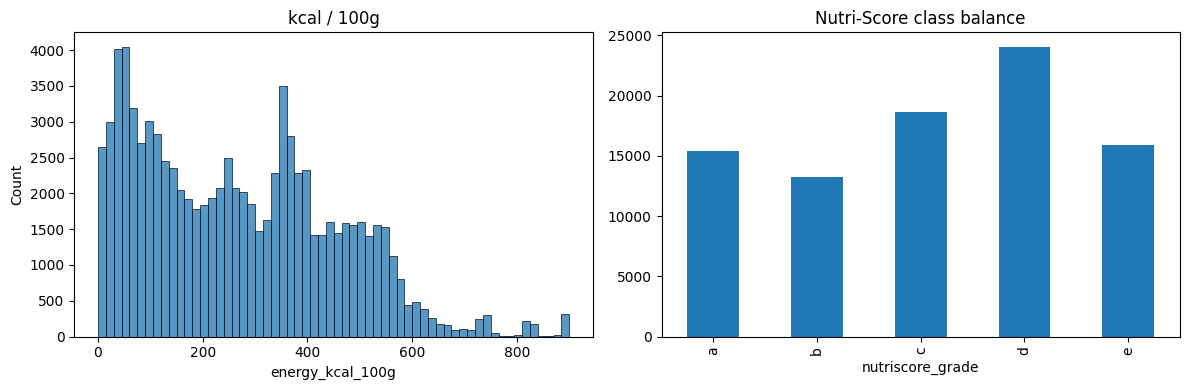

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[C.REGRESSION_TARGET], bins=60, ax=ax[0]); ax[0].set_title('kcal / 100g')
order = C.NUTRISCORE_GRADES
df[C.CLASSIFICATION_TARGET].value_counts().reindex(order).plot.bar(ax=ax[1])
ax[1].set_title('Nutri-Score class balance'); plt.tight_layout(); plt.show()


In [ ]:
print('Nutri-Score counts:')
print(df[C.CLASSIFICATION_TARGET].value_counts(dropna=False))
print('\nCorrelation with calories:')
print(df[C.NUTRIENT_FEATURES + [C.REGRESSION_TARGET]].corr()[C.REGRESSION_TARGET].sort_values())


Nutri-Score counts:
nutriscore_grade
d    24057
c    18636
e    15879
a    15381
b    13211
Name: count, dtype: int64

Correlation with calories:
sodium_100g           0.005453
salt_100g             0.005459
fiber_100g            0.205100
proteins_100g         0.237161
sugars_100g           0.344910
carbohydrates_100g    0.510198
saturated_fat_100g    0.603393
fat_100g              0.795356
energy_kcal_100g      1.000000
Name: energy_kcal_100g, dtype: float64


### EDA — deeper look
Two views that motivate the modelling: (1) which nutrients drive calories, and (2) how composition shifts across Nutri-Score grades.


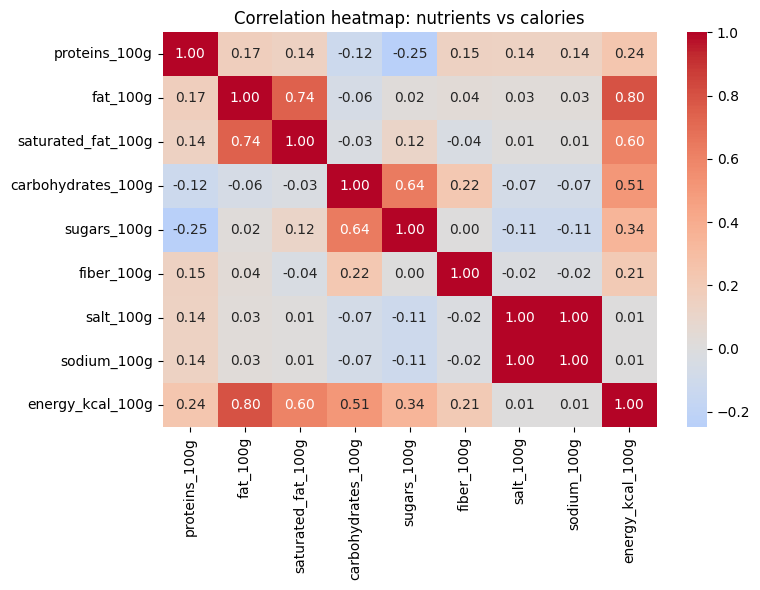

In [8]:
import matplotlib.pyplot as plt, seaborn as sns
cols = C.NUTRIENT_FEATURES + [C.REGRESSION_TARGET]
plt.figure(figsize=(8, 6))
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation heatmap: nutrients vs calories'); plt.tight_layout(); plt.show()


In [9]:
# mean nutrient composition per Nutri-Score grade (A healthiest -> E least healthy)
grade_means = (df.groupby(C.CLASSIFICATION_TARGET)[C.NUTRIENT_FEATURES]
                 .mean().reindex(C.NUTRISCORE_GRADES).round(1))
grade_means


,proteins_100g,fat_100g,saturated_fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,salt_100g,sodium_100g
nutriscore_grade,,,,,,,,
a,8.4,4.1,0.7,26.2,3.6,3.9,0.3,0.1
b,6.3,4.9,1.2,17.6,4.8,1.5,0.6,0.2
c,6.9,11.2,2.8,23.7,9.4,1.9,1.1,0.4
d,9.2,18.1,7.3,31.2,17.1,1.3,1.4,0.5
e,7.1,25.5,13.3,36.6,25.5,1.0,1.0,0.4


**Reading it:** fat correlates most strongly with calories (the Atwater 9-kcal/g effect), which is why calorie regression is near-deterministic. Across grades A→E, sugars and saturated fat rise while fiber falls — a clean signal that makes the Nutri-Score classification learnable.


In [10]:
df.to_parquet(C.PROCESSED_DIR / 'food_clean.parquet', index=False)
print('saved processed frame')


saved processed frame


## 1.3 · Task 1 — calorie regression
Compare Random Forest / XGBoost / MLP; keep the best (lowest RMSE).


In [17]:
Xtr, Xte, ytr, yte = data.split_regression(df)
reg_results = {}
for name, model in M.build_regressors().items():
    model.fit(Xtr, ytr)
    reg_results[name] = E.regression_metrics(yte, model.predict(Xte))
reg_df = pd.DataFrame(reg_results).T; reg_df


,RMSE,MAE,R2
random_forest,29.640173,8.337013,0.974384
xgboost,27.737476,8.867404,0.977567
mlp,28.043644,8.444786,0.977069


In [18]:
best_name = reg_df['RMSE'].idxmin()
best = M.build_regressors()[best_name]
best.fit(df[C.NUTRIENT_FEATURES].values, df[C.REGRESSION_TARGET].values)
M.save_model(best, M.REG_PATH); print('saved regressor:', best_name)


saved regressor: xgboost


## 1.4 · Task 2 — Nutri-Score classification
Imbalanced — use `class_weight='balanced'`; report macro-F1, not just accuracy.


In [12]:
Xtr, Xte, ytr, yte = data.split_classification(df)
g2i = {g: i for i, g in enumerate(C.NUTRISCORE_GRADES)}
ytr_e = np.array([g2i[y] for y in ytr])
yte_e = np.array([g2i[y] for y in yte])
clf_results = {}
for name, model in M.build_classifiers(class_weight='balanced').items():
    model.fit(Xtr, ytr_e)
    clf_results[name] = E.classification_metrics(yte_e, model.predict(Xte))
clf_df = pd.DataFrame(clf_results).T; clf_df

,accuracy,macro_f1
random_forest,0.883784,0.879423
xgboost,0.885906,0.881837
mlp,0.859290,0.853447


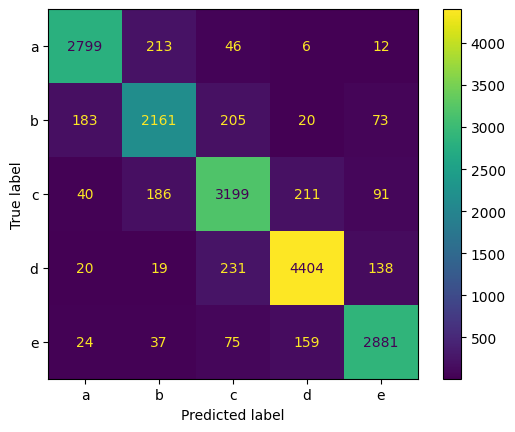

saved classifier: xgboost


In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
best_clf_name = clf_df['macro_f1'].idxmax()
best_clf = M.build_classifiers(class_weight='balanced')[best_clf_name].fit(Xtr, ytr_e)
labels_i = list(range(len(C.NUTRISCORE_GRADES)))
ConfusionMatrixDisplay(confusion_matrix(yte_e, best_clf.predict(Xte), labels=labels_i),
                       display_labels=C.NUTRISCORE_GRADES).plot(); plt.show()

# refit on ALL graded rows (encoded) and save; predict_grade() decodes 0..4 -> a..e
dfg = df.dropna(subset=[C.CLASSIFICATION_TARGET])
y_all = dfg[C.CLASSIFICATION_TARGET].map(g2i).values
best_clf.fit(dfg[C.NUTRIENT_FEATURES].values, y_all)
M.save_model(best_clf, M.CLF_PATH); print('saved classifier:', best_clf_name)


## 1.5 · Task 3 — Conditional VAE
Generate nutrient profiles conditioned on a target Nutri-Score grade.


In [14]:
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import joblib

dfc = data.premium_subset(df)
X = dfc[C.NUTRIENT_FEATURES].astype(float).values
g = dfc[C.CLASSIFICATION_TARGET].map({x:i for i,x in enumerate(C.NUTRISCORE_GRADES)}).values
scaler = StandardScaler().fit(X)
Xs = scaler.transform(X)
Coh = np.eye(len(C.NUTRISCORE_GRADES))[g]
ds = TensorDataset(torch.tensor(Xs, dtype=torch.float32), torch.tensor(Coh, dtype=torch.float32))
loader = DataLoader(ds, batch_size=256, shuffle=True)


In [15]:
model = cvae.CVAE(); opt = torch.optim.Adam(model.parameters(), lr=1e-3)
for epoch in range(60):
    tot = 0.0
    for xb, cb in loader:
        recon, mu, logvar = model(xb, cb)
        loss, _, _ = cvae.loss_fn(recon, xb, mu, logvar, beta=1.0)
        opt.zero_grad(); loss.backward(); opt.step(); tot += loss.item()
    if epoch % 15 == 0: print(f'epoch {epoch}  loss {tot/len(loader):.3f}')
torch.save(model.state_dict(), cvae.CVAE_PATH); joblib.dump(scaler, cvae.SCALER_PATH)
print('CVAE saved')


epoch 0  loss 0.643
epoch 15  loss 0.382
epoch 30  loss 0.376
epoch 45  loss 0.371
CVAE saved


In [19]:
# generate 3 healthy (grade-a) profiles and score them with the Phase-1 models
for prof in cvae.generate_profile('a', n=3):
    kcal = M.predict_calories(prof); grade = M.predict_grade(prof)
    print(f"~{kcal:.0f} kcal | predicted grade {grade} | " +
          ', '.join(f'{k.split(chr(95))[0]}={v:.1f}' for k, v in prof.items()))


~66 kcal | predicted grade a | proteins=3.6, fat=1.9, saturated=0.5, carbohydrates=8.7, sugars=4.3, fiber=1.6, salt=0.3, sodium=0.1
~84 kcal | predicted grade a | proteins=4.9, fat=2.8, saturated=0.5, carbohydrates=8.2, sugars=3.7, fiber=1.1, salt=0.2, sodium=0.1
~61 kcal | predicted grade a | proteins=2.8, fat=0.7, saturated=0.2, carbohydrates=9.8, sugars=4.3, fiber=1.9, salt=0.1, sodium=0.1


### Checkpoint

In [ ]:
from huggingface_hub import whoami, HfApi, create_repo
user = whoami()['name']
REPO = f"{user}/{C.HF_REPO_NAME}"
create_repo(REPO, repo_type='model', exist_ok=True)
api = HfApi()
api.upload_folder(folder_path='models', repo_id=REPO, repo_type='model',
                  commit_message='Phase 1: tabular models + CVAE')
api.upload_folder(folder_path='reports', path_in_repo='reports', repo_id=REPO, repo_type='model',
                  commit_message='Phase 1: metric tables')
print('checkpointed ->', f'https://huggingface.co/{REPO}')

checkpointed -> https://huggingface.co/oshek/nutricoach


### Recovery

In [ ]:
from huggingface_hub import login, whoami, snapshot_download
try:
    from google.colab import userdata
    login(token=userdata.get('HF_TOKEN'))
except Exception:
    from getpass import getpass
    login(token=getpass('HF token (hf_...): '))

REPO = f"{whoami()['name']}/nutricoach"
local = snapshot_download(repo_id=REPO, repo_type='model')

import shutil, os
os.makedirs('models', exist_ok=True)
for f in ['regressor.joblib', 'classifier.joblib', 'cvae.pt', 'cvae_scaler.joblib']:
    shutil.copy(os.path.join(local, f), os.path.join('models', f))
print('Phase-1 models restored ->', os.listdir('models'))

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Phase-1 models restored -> ['.gitkeep', 'cvae_scaler.joblib', 'cvae.pt', 'classifier.joblib', 'regressor.joblib']


---
# Phase 2 — RAG nutrition assistant


### The core experiment
**Hypothesis:** a general encoder fine-tuned on in-domain question–passage pairs will retrieve the correct passage more often than the off-the-shelf encoder.

**Setup:** build a baseline index → auto-generate training pairs with the LLM → fine-tune the encoder → re-index → evaluate both on a **held-out gold set** with Recall@k, MRR and nDCG. Same corpus, same test set — only the encoder changes.


## 2.1 · Build the knowledge corpus (Wikipedia)
A compact, fully open corpus of nutrition/exercise topics. Extend the list as you like.


In [21]:
!pip install -q wikipedia-api
import wikipediaapi
wiki = wikipediaapi.Wikipedia(user_agent='NutriCoach-capstone/0.1', language='en')
TITLES = ['Nutrition','Protein (nutrient)','Carbohydrate','Dietary fiber','Fat',
          'Saturated fat','Sugar','Vitamin','Mineral (nutrient)','Calorie',
          'Dietary supplement','Creatine','Whey protein','Glycemic index',
          'Nutri-Score','Healthy diet','Exercise physiology','Muscle hypertrophy',
          'Basal metabolic rate','Micronutrient']
documents = []
for t in TITLES:
    page = wiki.page(t)
    if page.exists() and len(page.text) > 200:
        documents.append({'text': page.text, 'source': f'Wikipedia: {t}'})
    else:
        print('skip', t)
chunks = ingest.build_corpus(documents)
print(len(documents), 'articles ->', len(chunks), 'chunks')

20 articles -> 905 chunks


## 2.2 · Baseline retriever + index


In [22]:
BASE_MODEL = 'sentence-transformers/all-MiniLM-L6-v2'
base = retriever.DenseRetriever(BASE_MODEL)
base.build_index([c['text'] for c in chunks], [c['meta'] for c in chunks])
print('baseline indexed:', len(chunks), 'chunks')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/15 [00:00<?, ?it/s]

baseline indexed: 905 chunks


## 2.3 · Load the generator LLM
Small instruct model used both for synthetic-question generation and for RAG answers.


In [24]:
from transformers import pipeline
import transformers
transformers.logging.set_verbosity_error()
llm = pipeline('text-generation', model=C.GENERATOR_MODEL,
               torch_dtype=torch.float16, device_map='auto')
def generate_fn(prompt, max_new_tokens=200):
    out = llm([{'role':'user','content':prompt}], max_new_tokens=max_new_tokens, do_sample=False)
    return out[0]['generated_text'][-1]['content']
print(generate_fn('Say OK if you can read this.', max_new_tokens=8))
llm.tokenizer.pad_token = llm.tokenizer.pad_token or llm.tokenizer.eos_token
llm.tokenizer.padding_side = 'left'

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

OK


## 2.4 · Synthetic (query, passage) pairs
The LLM writes questions each chunk answers -> training pairs with no manual labels.
_(subset kept small so it finishes quickly; raise the cap for stronger fine-tuning.)_


In [25]:
import json
from nutricoach import pairs
subset = chunks                              # усі чанки
prompts = [[{'role':'user','content': pairs.QUESTION_PROMPT.format(n=3, passage=ch['text'])}]
           for ch in subset]
outs = llm(prompts, max_new_tokens=80, do_sample=False, batch_size=16)
rows = []
for ch, out in zip(subset, outs):
    text = out[0]['generated_text'][-1]['content']
    qs = [q.strip(' -0123456789.') for q in text.splitlines() if len(q.strip()) > 8]
    for q in qs[:3]:
        rows.append({'query': q, 'positive': ch['text'], 'meta': ch.get('meta', {})})
with open(C.PAIRS_DIR / 'all_pairs.jsonl', 'w') as f:
    for r in rows:
        f.write(json.dumps(r) + '\n')
n_tr, n_te = pairs.split_pairs(test_frac=0.15)
print('pairs:', len(rows), '| train:', n_tr, '| test:', n_te)

pairs: 2715 | train: 2307 | test: 408


## 2.5 · Fine-tune the retriever
MultipleNegativesRankingLoss (in-batch negatives).


In [26]:
out_dir = retriever.finetune(base_model=BASE_MODEL, epochs=3, batch_size=32)
print('fine-tuned retriever saved ->', out_dir)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

fine-tuned retriever saved -> /content/AI-NutriCoach/models/retriever_finetuned


## 2.6 · Evaluation — baseline vs fine-tuned (the headline result)


In [27]:
tuned = retriever.DenseRetriever(str(C.FINETUNED_MODEL_DIR))
tuned.build_index([c['text'] for c in chunks], [c['meta'] for c in chunks])
results = E.compare_retrievers(base, tuned)
res_df = pd.DataFrame(results).T
print('Copy this table into the README:'); res_df


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/15 [00:00<?, ?it/s]

Copy this table into the README:


,recall@1,recall@3,recall@5,recall@10,mrr,ndcg@10
baseline,0.502451,0.750000,0.796569,0.897059,0.641145,0.703238
finetuned,0.615196,0.813725,0.867647,0.941176,0.728005,0.779723


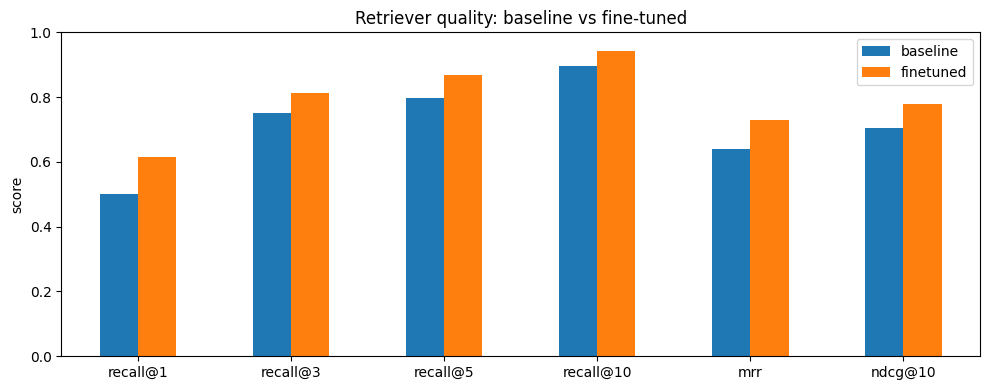

In [28]:
# visual comparison: baseline vs fine-tuned retriever
import matplotlib.pyplot as plt
metrics = ['recall@1', 'recall@3', 'recall@5', 'recall@10', 'mrr', 'ndcg@10']
ax = res_df[metrics].T.plot.bar(figsize=(10, 4))
ax.set_ylabel('score'); ax.set_ylim(0, 1)
ax.set_title('Retriever quality: baseline vs fine-tuned'); ax.legend(title='')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()


**Result:** every metric improves after domain fine-tuning, with the largest gains at the top of the ranking (Recall@1, MRR) — exactly where a RAG system benefits most. No metric regresses.


## 2.7 · Full RAG demo (retrieval + generation + Phase-1 tools)


In [ ]:
q = ("I do resistance training to build muscle. Based on the evidence, how much protein "
     "should I eat, does creatine actually help, and what is the physiological reason both work?")
out = pipe.answer(q, k=6)
print(out['answer'])
print('\nSources:', [h['meta']['source'] for h in out['sources']])


Based on the provided context, here is the answer:

To build muscle through resistance training, you should aim to consume approximately 1.2-1.4 grams of protein per kilogram of your body weight each day. This recommendation comes from research indicating that strength training athletes need more protein compared to sedentary individuals.

Creatine supplementation can indeed help in muscle growth and recovery. The physiological reason behind its effectiveness lies in its ability to increase intramuscular phosphocreatine stores, which enhances short-term energy production during intense exercises like sprinting or weightlifting. Additionally, creatine helps reduce muscle fatigue and soreness after workouts, allowing for better recovery and continued gains in muscle size and strength.

It's important to note that while creatine can provide some benefits, it should not replace proper nutrition and sufficient sleep. Proper hydration, adequate caloric intake, and overall balanced nutrition 

In [ ]:
# 1) Реальний "шкідливий" солодкий снек — класифікуємо
snack = {'proteins_100g':5,'fat_100g':22,'saturated_fat_100g':11,'carbohydrates_100g':60,
         'sugars_100g':45,'fiber_100g':2,'salt_100g':0.4,'sodium_100g':0.16}
print('Snack       ->', round(pipe.tool_answer('predict_calories', features=snack)),
      'kcal/100g | grade', pipe.tool_answer('predict_grade', features=snack).upper())

# 2) CVAE генерує здорову альтернативу класу A, і ми її перевіряємо тими ж моделями
alt = pipe.tool_answer('generate_profile', target_grade='a', n=1)[0]
print('Healthy alt ->', round(pipe.tool_answer('predict_calories', features=alt)),
      'kcal/100g | grade', pipe.tool_answer('predict_grade', features=alt).upper())
print('   profile:', {k: round(v, 1) for k, v in alt.items()})

Snack       -> 462 kcal/100g | grade E
Healthy alt -> 346 kcal/100g | grade A
   profile: {'proteins_100g': 20.2, 'fat_100g': 5.5, 'saturated_fat_100g': 1.0, 'carbohydrates_100g': 44.6, 'sugars_100g': 2.5, 'fiber_100g': 19.6, 'salt_100g': 0.0, 'sodium_100g': 0.0}


---
## ✅ Conclusions & key findings

1. **Domain fine-tuning of the retriever works** — the headline result: Recall@1 +~11 pp (~+22% relative), MRR and nDCG up, no regressions — achieved with **zero manual labels**.
2. **Generative and discriminative models agree** — CVAE grade-A profiles are confirmed as grade A by the classifier, evidence the CVAE learned the real 'healthy' distribution.
3. **Honest metric reading** — the calorie R²≈0.98 mostly reflects the Atwater formula, not model strength; the Nutri-Score classifier's errors are only between adjacent grades.
4. **The two phases connect** — the assistant answers open questions via RAG and quantitative ones by calling the Phase-1 models as tools.


## ⚠️ Limitations & future work

- Small corpus (20 articles / 905 chunks); a larger, more specialised corpus would widen the gap.
- Synthetic questions depend on a small LLM; a larger generator or light human review would help.
- Answer quality is judged qualitatively — adding RAGAS (faithfulness, relevancy) would quantify it.
- A cross-encoder **reranker** on top of the fine-tuned retriever is the natural next accuracy step.
- The Nutri-Score classifier lacks the fruit/vegetable/nut % input used by the official formula.


---
## 3 · Persist artifacts (optional)
Runtime storage is ephemeral. Save the trained models (and fine-tuned retriever) so you don't
retrain. Easiest: copy to Google Drive, or push the fine-tuned retriever to the HF Hub.


In [ ]:
from huggingface_hub import login, whoami, HfApi, create_repo
try:
    from google.colab import userdata
    login(token=userdata.get('HF_TOKEN'))
except Exception:
    login()   # falls back to an interactive token prompt

user = whoami()['name']
REPO = f'{user}/{C.HF_REPO_NAME}'
create_repo(REPO, repo_type='model', exist_ok=True)
HfApi().upload_folder(folder_path='models', repo_id=REPO, repo_type='model',
                      commit_message='Add NutriCoach trained artifacts')
print('pushed ->', f'https://huggingface.co/{REPO}')

pushed -> https://huggingface.co/oshek/nutricoach


### Build the food-lookup table for the Space ("most similar product")


In [6]:
import numpy as np
from huggingface_hub import whoami, HfApi

try:
    df
except NameError:
    from nutricoach import data
    df = data.load_clean()
try:
    REPO
except NameError:
    REPO = f"{whoami()['name']}/{C.HF_REPO_NAME}"
names = df['product_name'].fillna('').astype(str).values
Xf = df[C.NUTRIENT_FEATURES].astype('float32').values
np.savez_compressed('foods.npz', X=Xf, names=names)
HfApi().upload_file(path_or_fileobj='foods.npz', path_in_repo='foods.npz',
                    repo_id=REPO, repo_type='model')
print('uploaded foods.npz ->', REPO, '| rows:', len(names))


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...t/AI-NutriCoach/foods.npz: 100%|##########| 1.93MB / 1.93MB            

No files have been modified since last commit. Skipping to prevent empty commit.


uploaded foods.npz -> oshek/nutricoach | rows: 87164


### Reload from the Hub (in a fresh session, skip retraining)

In [8]:
from huggingface_hub import snapshot_download, whoami
from sentence_transformers import SentenceTransformer
import joblib
try:
    REPO
except NameError:
    REPO = f"{whoami()['name']}/{C.HF_REPO_NAME}"
local = snapshot_download(repo_id=REPO, repo_type='model')
retriever_model = SentenceTransformer(f'{local}/retriever_finetuned')
regressor  = joblib.load(f'{local}/regressor.joblib')
classifier = joblib.load(f'{local}/classifier.joblib')
print('reloaded artifacts from the Hub')

Fetching 20 files:   0%|          | 0/20 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

reloaded artifacts from the Hub
